# SAAM — Sustainability Aware Asset Management
## Pacific Region (PAC) | Scope 1 CO₂ Emissions

**Academic project** — Portfolio optimization with carbon constraints

- Region: **PAC** (Pacific)
- CO₂ Scope: **Scope 1 only**
- Rebalancing: Dec 2013 → Dec 2023 (annual)
- Performance evaluation: Jan 2014 → Dec 2024 (monthly)
- Preliminary submission: **April 12, 2026**
- Final submission: **May 29, 2026**

## 0. Setup & Imports

In [1]:
import re
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path
from sklearn.covariance import LedoitWolf

warnings.filterwarnings('ignore')

# Relative paths — notebook must be in the same folder as the data files.
DATA_PATH      = Path("Sustainability.xlsx")
RISK_FREE_PATH = Path("risk_free_tb3ms_2014_2024.csv")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

REBALANCE_YEARS = list(range(2013, 2024))   # Dec 2013 … Dec 2023
PERF_YEARS      = list(range(2014, 2025))   # Jan 2014 … Dec 2024
NZ_THETA        = 0.10                      # 10% annual CF reduction for net-zero

RF_SERIES = "TB3MS"                         # FRED: 3-Month Treasury Bill Secondary Market Rate, annualized %
RF_SOURCE = "FRED TB3MS (Board of Governors/Federal Reserve Bank of St. Louis)"
RF_START  = pd.Timestamp(f"{PERF_YEARS[0]}-01-01")
RF_END    = pd.Timestamp(f"{PERF_YEARS[-1]}-12-31")


def load_annualized_risk_free_rate(path=RISK_FREE_PATH, start=RF_START, end=RF_END):
    """Return the sample-average annualized risk-free rate as a decimal."""
    rf = pd.read_csv(path, parse_dates=["observation_date"])
    if RF_SERIES not in rf.columns:
        raise ValueError(f"{path} must contain a '{RF_SERIES}' column")

    rf[RF_SERIES] = pd.to_numeric(rf[RF_SERIES], errors="coerce")
    sample = rf.loc[
        (rf["observation_date"] >= start) &
        (rf["observation_date"] <= end),
        ["observation_date", RF_SERIES]
    ].dropna().copy()

    expected_months = len(pd.date_range(start=start, end=end, freq="MS"))
    if len(sample) != expected_months:
        raise ValueError(
            f"Risk-free sample has {len(sample)} monthly observations; "
            f"expected {expected_months} from {start.date()} to {end.date()}."
        )

    return float(sample[RF_SERIES].mean() / 100.0), sample


RF_ANN, rf_monthly = load_annualized_risk_free_rate()

print("Libraries loaded.")
print(f"Data file found: {DATA_PATH.exists()}")
print(f"Risk-free file found: {RISK_FREE_PATH.exists()}")
print(f"Risk-free rate used in Sharpe ratios: {RF_ANN:.4%} ({RF_SOURCE}, {RF_START.date()} to {RF_END.date()})")


Libraries loaded.
Data file found: True
Risk-free file found: True
Risk-free rate used in Sharpe ratios: 1.6181% (FRED TB3MS (Board of Governors/Federal Reserve Bank of St. Louis), 2014-01-01 to 2024-12-31)


### Methodological Choices

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Risk-free rate | Historical 3-month US T-Bill average (FRED TB3MS), Jan 2014–Dec 2024 | Sharpe uses annualized returns, so $R_f$ is the arithmetic average of the monthly annualized TB3MS observations over the same performance window |
| Min return observations | ≥ 60 months (5 years) | More conservative than the 36-month minimum suggested — ensures reliable covariance estimation |
| Stale price denominator | $\tau = 120$ (full window) | Proportion computed over all months, including NaN periods |
| Missing return imputation | Per-firm mean | Avoids compressing variance toward zero for data-sparse firms |
| Covariance estimator | Ledoit-Wolf shrinkage | Ensures full-rank $\hat{\Sigma}$ when $N > \tau$ (from Dec 2017); resolves tracking-error degeneracy between $P_{oos}^{(vw)}(0.5)$ and $P_{oos}^{(vw)}(NZ)$ |
| VW benchmark weights | Lagged by one month ($t-1$) | Avoids forward-looking bias: end-of-month cap already reflects $R_{i,t}$ |
| Scope 1 zeros | Treated as missing (NaN) | Early-year zeros in Datastream typically indicate unreported data, not zero emissions |
| Unlabeled delistings | $-100\%$ at first NaN with $\geq 6$ trailing NaN months | Conservative heuristic for firms that stop trading without an explicit DELIST/DEAD label |


## 1. Data Loading

In [2]:
print("Loading Excel sheets (this may take ~30 s)...")

static    = pd.read_excel(DATA_PATH, sheet_name="Statistic")
to_delete = pd.read_excel(DATA_PATH, sheet_name="Entreprise a supprimé de tout")
ri_m      = pd.read_excel(DATA_PATH, sheet_name="RI Pac Month")
mktcap_m  = pd.read_excel(DATA_PATH, sheet_name="Market cap PAC month")
mktcap_y  = pd.read_excel(DATA_PATH, sheet_name="Market cap PAC year")
rev_y     = pd.read_excel(DATA_PATH, sheet_name="Revenue PAC annual")
scope1_y  = pd.read_excel(DATA_PATH, sheet_name="Émission Pac scope 1")

print("All sheets loaded.")

Loading Excel sheets (this may take ~30 s)...
All sheets loaded.


In [3]:
# --- Monthly sheets: index=ISIN, columns=datetime ---
for df in [ri_m, mktcap_m]:
    df.set_index("ISIN", inplace=True)
    df.drop(columns=["NAME"], inplace=True, errors="ignore")
    df.columns = pd.to_datetime(df.columns)

# --- Annual sheets: index=ISIN, columns=int year, numeric coercion ---
# Some cells contain string error codes (e.g., '$$ER:...'). Coerce to NaN.
for df in [mktcap_y, rev_y, scope1_y]:
    df.set_index("ISIN", inplace=True)
    df.drop(columns=["NAME"], inplace=True, errors="ignore")
    df.columns = df.columns.astype(int)
    df[:] = df.apply(pd.to_numeric, errors="coerce")

# Name lookup
isin_to_name = static.set_index("ISIN")["NAME"].to_dict()

print(f"RI monthly  : {ri_m.shape}  ({ri_m.columns[0].date()} → {ri_m.columns[-1].date()})")
print(f"Market cap M: {mktcap_m.shape}")
print(f"Mkt cap Y   : {mktcap_y.shape}")
print(f"Revenue Y   : {rev_y.shape}")
print(f"Scope 1 Y   : {scope1_y.shape}")

RI monthly  : (510, 314)  (1999-12-31 → 2026-01-30)
Market cap M: (510, 314)
Mkt cap Y   : (510, 27)
Revenue Y   : (510, 27)
Scope 1 Y   : (510, 27)


## 2. Data Cleaning

### 2.1 Drop firms from the exclusion list

In [4]:
# Keep only valid 12-character ISIN codes (skip note rows in the sheet)
isins_to_delete = [
    x for x in to_delete["ISIN"].dropna().tolist()
    if isinstance(x, str) and len(x) == 12 and x[:2].isalpha()
]
print(f"ISINs to exclude: {isins_to_delete}")

for df in [ri_m, mktcap_m, mktcap_y, rev_y, scope1_y]:
    df.drop(index=isins_to_delete, inplace=True, errors="ignore")

print(f"Firms remaining: {len(ri_m)}")

ISINs to exclude: ['AU000000BWP3', 'JP3164630000', 'JP3819400007']
Firms remaining: 510


In [5]:
# Drop firms with no return data at all
all_nan_mask  = ri_m.isna().all(axis=1)
all_nan_isins = ri_m.index[all_nan_mask].tolist()

if all_nan_isins:
    print(f"Dropping {len(all_nan_isins)} firms with entirely missing RI data")
    for df in [ri_m, mktcap_m, mktcap_y, rev_y, scope1_y]:
        df.drop(index=all_nan_isins, inplace=True, errors="ignore")
else:
    print(f"No firms with entirely missing RI — none to drop.")


No firms with entirely missing RI — none to drop.


### 2.2 Emission zeros → NaN

Unreported early-year emissions are stored as 0. We treat zeros as missing so that forward-fill propagates the last known reported value.

In [6]:
scope1_y_clean = scope1_y.replace(0, np.nan)

print("Non-NaN emission observations per year:")
for yr in range(2008, 2025):
    if yr in scope1_y_clean.columns:
        n = scope1_y_clean[yr].notna().sum()
        print(f"  {yr}: {n:3d} firms with Scope 1 data")

Non-NaN emission observations per year:
  2008:  67 firms with Scope 1 data
  2009: 109 firms with Scope 1 data
  2010: 165 firms with Scope 1 data
  2011: 158 firms with Scope 1 data
  2012: 180 firms with Scope 1 data
  2013: 187 firms with Scope 1 data
  2014: 172 firms with Scope 1 data
  2015: 197 firms with Scope 1 data
  2016: 234 firms with Scope 1 data
  2017: 279 firms with Scope 1 data
  2018: 324 firms with Scope 1 data
  2019: 374 firms with Scope 1 data
  2020: 413 firms with Scope 1 data
  2021: 448 firms with Scope 1 data
  2022: 471 firms with Scope 1 data
  2023: 474 firms with Scope 1 data
  2024: 454 firms with Scope 1 data


### 2.3 Low-price filter (RI < 0.50 → NaN)

In [7]:
ri_m_clean = ri_m.copy().astype(float)
low_price_mask = ri_m_clean < 0.50
ri_m_clean[low_price_mask] = np.nan
print(f"Low-price observations replaced with NaN: {low_price_mask.sum().sum():,}")

Low-price observations replaced with NaN: 8,625


### 2.4 Monthly returns from cleaned total return index

In [8]:
# fill_method=None: don't pad NaN prices before computing returns
ret_m = ri_m_clean.pct_change(axis=1, fill_method=None).iloc[:, 1:]

print(f"Monthly returns shape : {ret_m.shape}")
print(f"Date range            : {ret_m.columns[0].date()} → {ret_m.columns[-1].date()}")

Monthly returns shape : (510, 313)
Date range            : 2000-01-31 → 2026-01-30


### 2.5 Delisted firms — inject −100% return at delisting month

In [9]:
# Pattern 1: explicit date in name  "DELIST.MM/YY" or "DELIST MM/YY"
date_pattern   = re.compile(r'DELIST[.\s-]*(\d{1,2})[/\-](\d{2,4})', re.IGNORECASE)
# Pattern 2: no date — fall back to injecting at first NaN after last valid return
dead_pattern   = re.compile(r'DEAD', re.IGNORECASE)

n_date_inject  = 0
n_fallback_inject = 0

for isin, name in isin_to_name.items():
    if isin not in ret_m.index:
        continue
    name_str = str(name)

    m = date_pattern.search(name_str)
    if m:
        mo = int(m.group(1))
        yr = int(m.group(2))
        if yr < 100:
            yr += 2000
        # Find the matching month column in ret_m
        target_cols = [c for c in ret_m.columns if c.year == yr and c.month == mo]
        if target_cols:
            col = target_cols[0]
            # Only inject if currently NaN (firm truly delisted — not still trading)
            if pd.isna(ret_m.loc[isin, col]):
                ret_m.loc[isin, col] = -1.0
                n_date_inject += 1
    elif dead_pattern.search(name_str):
        # No date in name: use last_valid_index approach
        last_valid = ret_m.loc[isin].last_valid_index()
        if last_valid is not None:
            future_cols = [c for c in ret_m.columns if c > last_valid]
            # Only inject if the firm has stopped trading before the end of the data
            if future_cols and future_cols[0] < ret_m.columns[-1]:
                ret_m.loc[isin, future_cols[0]] = -1.0
                n_fallback_inject += 1

print(f"Delisting returns injected — date-based: {n_date_inject}, fallback: {n_fallback_inject}, total: {n_date_inject + n_fallback_inject}")

Delisting returns injected — date-based: 1, fallback: 1, total: 2


In [10]:
# Firms with no explicit DELIST/DEAD label but ≥ 6 trailing NaN months: inject -100%
n_unlabeled = 0

for isin in ret_m.index:
    name_str = str(isin_to_name.get(isin, ""))
    # Skip if already handled by the labelled-delisting block above
    if date_pattern.search(name_str) or dead_pattern.search(name_str):
        continue
    last_valid = ret_m.loc[isin].last_valid_index()
    if last_valid is None:
        continue
    future_cols = [c for c in ret_m.columns if c > last_valid]
    if len(future_cols) >= 6:                          # ≥ 6 trailing NaN months
        first_nan_col = future_cols[0]
        if pd.isna(ret_m.loc[isin, first_nan_col]):    # not already injected
            ret_m.loc[isin, first_nan_col] = -1.0
            n_unlabeled += 1

print(f"Unlabeled delisting returns injected: {n_unlabeled}")

Unlabeled delisting returns injected: 7


### 2.6 Forward-fill annual data

Mid/end-year missing data is filled forward. Beginning-of-series NaN remains NaN → firm is ineligible until first non-NaN.

In [11]:
rev_y_filled    = rev_y.ffill(axis=1)
scope1_y_filled = scope1_y_clean.ffill(axis=1)
mktcap_y_clean  = mktcap_y.replace(0, np.nan)   # 0 market cap = missing

print(f"Revenue  2013 non-NaN : {rev_y_filled[2013].notna().sum()} firms")
print(f"Scope 1  2013 non-NaN : {scope1_y_filled[2013].notna().sum()} firms")
print(f"Mkt cap  2013 non-NaN : {mktcap_y_clean[2013].notna().sum()} firms")

Revenue  2013 non-NaN : 510 firms
Scope 1  2013 non-NaN : 260 firms
Mkt cap  2013 non-NaN : 506 firms


## 3. Investment Set Construction (Annual)

For each rebalancing year Y, a firm is eligible if **all** conditions hold:

| # | Condition | Threshold |
|---|-----------|----------|
| 1 | PAC region | Guaranteed (PAC-only sheets) |
| 2 | Return observations | ≥ 36 non-NaN months in 10-year window |
| 3 | Carbon & revenue data | Scope 1 and Revenue non-NaN (after ffill) at year Y |
| 4 | Price level | RI at Dec Y ≥ 0.50 |
| 5 | Stale prices | < 50% monthly returns exactly zero |

In [12]:
def build_investment_set(Y, ret_m, ri_m_clean, rev_y_filled, scope1_y_filled, tau=120):
    """Returns list of ISINs eligible at Dec Y rebalancing date."""
    # Find Dec Y column
    dec_cols = [c for c in ret_m.columns if c.year == Y and c.month == 12]
    if not dec_cols:
        raise ValueError(f"No December {Y} column found in return data")
    dec_Y = dec_cols[0]

    # tau-month lookback window ending at Dec Y
    cols_up_to_dec = [c for c in ret_m.columns if c <= dec_Y]
    window_cols    = cols_up_to_dec[-tau:]
    ret_window     = ret_m[window_cols]

    # C2: min 60 non-NaN observations (5 years out of 10).
    # The PDF says "e.g. less than 3 years" as a minimum; we use 5 years so
    # that the covariance estimate rests on sufficient data and the mean
    # imputation bias (see estimate_moments) remains moderate.
    cond2 = ret_window.notna().sum(axis=1) >= 60

    # C3: carbon and revenue data available at year Y
    cond3 = (
        scope1_y_filled[Y].notna() &
        rev_y_filled[Y].notna()    &
        (rev_y_filled[Y] > 0)
    ) if Y in scope1_y_filled.columns else pd.Series(False, index=ret_m.index)

    # C4: price at Dec Y not NaN
    cond4 = ri_m_clean[dec_Y].notna()

    # C5: < 50% stale returns
    zero_prop = (ret_window == 0).sum(axis=1) / tau
    cond5 = zero_prop < 0.50

    eligible = cond2 & cond3 & cond4 & cond5
    eligible = eligible.reindex(ret_m.index).fillna(False)
    return ret_m.index[eligible].tolist()


investment_sets = {}
print("Investment set sizes:")
for Y in REBALANCE_YEARS:
    investment_sets[Y] = build_investment_set(
        Y, ret_m, ri_m_clean, rev_y_filled, scope1_y_filled
    )
    print(f"  Dec {Y}: {len(investment_sets[Y]):3d} eligible firms")

Investment set sizes:
  Dec 2013: 254 eligible firms
  Dec 2014: 264 eligible firms
  Dec 2015: 284 eligible firms
  Dec 2016: 309 eligible firms
  Dec 2017: 336 eligible firms
  Dec 2018: 362 eligible firms
  Dec 2019: 400 eligible firms
  Dec 2020: 423 eligible firms
  Dec 2021: 453 eligible firms
  Dec 2022: 468 eligible firms
  Dec 2023: 468 eligible firms


## 4. Part I — Minimum-Variance Portfolio

### 4a. Parameter Estimation

In [13]:
def estimate_moments(Y, investment_set, ret_m, tau=120):
    """Estimate (μ, Σ) from tau-month lookback window ending Dec Y."""
    dec_Y = [c for c in ret_m.columns if c.year == Y and c.month == 12][0]
    cols  = [c for c in ret_m.columns if c <= dec_Y][-tau:]
    R     = ret_m.loc[investment_set, cols].astype(float)

    # NaN imputed with each firm's own mean over available months
    firm_means = R.mean(axis=1)           # ignores NaN
    R = R.apply(lambda row: row.fillna(firm_means[row.name]), axis=1)

    mu    = R.mean(axis=1).values

    # Ledoit-Wolf: full-rank Σ when N > τ (occurs from Dec 2017)
    lw    = LedoitWolf().fit(R.values.T)   # R.T shape: (τ, N)
    Sigma = lw.covariance_                 # shape: (N, N), full-rank
    Sigma += 1e-8 * np.eye(len(investment_set))   # numerical stability for OSQP
    return mu, Sigma

### 4b. Optimisation — Long-only Min-Variance QP

$$\min_{\alpha} \; \alpha^\top \Sigma \alpha \quad \text{s.t.} \; \mathbf{1}^\top\alpha = 1, \; \alpha \geq 0$$

In [14]:
def solve_min_variance(Sigma):
    """Long-only minimum-variance QP. Returns weight vector (N,)."""
    N     = Sigma.shape[0]
    alpha = cp.Variable(N)
    prob  = cp.Problem(
        cp.Minimize(cp.quad_form(alpha, Sigma)),
        [cp.sum(alpha) == 1, alpha >= 0]
    )
    prob.solve(solver=cp.OSQP, warm_start=True, eps_abs=1e-8, eps_rel=1e-8, max_iter=10000)
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"Min-variance solver failed: {prob.status}")
    w = np.clip(np.array(alpha.value).flatten(), 0, None)
    return w / w.sum()

### 4c. Value-Weighted Benchmark

In [15]:
def compute_vw_weights(t, investment_set, mktcap_m):
    """Market-cap weights at monthly date t."""
    caps  = mktcap_m.loc[investment_set, t].astype(float).fillna(0)
    total = caps.sum()
    return (caps / total).values if total > 0 else np.ones(len(investment_set)) / len(investment_set)

### 4d. Ex-post Monthly Returns (buy-and-hold weight drift)

In [16]:
def compute_portfolio_returns(alpha_0, investment_set, ret_m, perf_year):
    """Returns (list_of_monthly_returns, list_of_months) for perf_year."""
    months  = sorted([c for c in ret_m.columns if c.year == perf_year])
    if not months:
        return [], []
    R       = ret_m.loc[investment_set, months].astype(float).fillna(0).values  # N×T
    alpha_t = alpha_0.copy()
    port_r  = []
    for k in range(R.shape[1]):
        R_k  = R[:, k]
        Rp_k = float(alpha_t @ R_k)
        port_r.append(Rp_k)
        denom = 1 + Rp_k
        alpha_t = alpha_t * (1 + R_k) / denom if abs(denom) > 1e-10 else np.zeros_like(alpha_t)
    return port_r, months


def compute_vw_portfolio_returns(investment_set, ret_m, mktcap_m, perf_year):
    """
    VW benchmark with lagged weights: w_{i,t-1} are used for return R_{i,t}.

    Using mktcap_m[t] directly would be forward-looking: end-of-month market
    cap at date t already incorporates R_{i,t} via price appreciation.
    Correct formula:  R^{vw}_t = Σ_i  w_{i,t-1} × R_{i,t}
    """
    months          = sorted([c for c in ret_m.columns if c.year == perf_year])
    all_mktcap_cols = sorted(mktcap_m.columns)
    port_r = []
    for t in months:
        prev_cols = [c for c in all_mktcap_cols if c < t]
        if not prev_cols:
            # No prior month available (should not occur: mktcap_m starts 1999)
            w = np.ones(len(investment_set)) / len(investment_set)
        else:
            w = compute_vw_weights(prev_cols[-1], investment_set, mktcap_m)
        R_t = ret_m.loc[investment_set, t].astype(float).fillna(0).values
        port_r.append(float(w @ R_t))
    return port_r, months

### 4e. Performance Statistics

In [17]:
def performance_stats(monthly_returns, label=None):
    r         = np.array(monthly_returns)
    T         = len(r)
    cum_ret   = np.prod(1 + r) - 1                    # R_p[T] = Prod(1+r_t) - 1
    mu_ann    = (1 + cum_ret) ** (12 / T) - 1         # CAGR = (1+R_p[T])^{12/T} - 1
    sigma_ann = r.std(ddof=1) * np.sqrt(12)
    sharpe    = (mu_ann - RF_ANN) / sigma_ann if sigma_ann > 0 else np.nan
    stats = {
        "Ann. Return":     mu_ann,
        "Ann. Volatility": sigma_ann,
        "Sharpe Ratio":    sharpe,
        "Min Monthly":     r.min(),
        "Max Monthly":     r.max(),
        "Cum. Return":     cum_ret,
    }
    if label:
        print(f"\n{'='*50}\n{label}\n{'='*50}")
        print(f"  Risk-free rate (ann.) : {RF_ANN:.4%}")
        for k, v in stats.items():
            fmt = f"{v:.4f}" if k == "Sharpe Ratio" else f"{v:.4%}"
            print(f"  {k:22s}: {fmt}")
    return stats


### 4f. Main Loop — Rebalance Dec 2013 → Dec 2023


In [18]:
results_mv = {}  # Y → {weights, isins, returns, months, mu, Sigma}
results_vw = {}  # Y → {isins, returns, months}

all_mv_returns = []
all_vw_returns = []
all_months     = []

print("Running min-variance optimisation loop...")
for Y in REBALANCE_YEARS:
    I_Y       = investment_sets[Y]
    perf_year = Y + 1

    perf_months = sorted([c for c in ret_m.columns if c.year == perf_year])
    if not perf_months:
        print(f"  {Y}: no return data for {perf_year} — skipping")
        continue

    mu, Sigma = estimate_moments(Y, I_Y, ret_m)

    # Min-variance
    alpha_mv         = solve_min_variance(Sigma)
    ret_mv, months_r = compute_portfolio_returns(alpha_mv, I_Y, ret_m, perf_year)

    # VW benchmark
    ret_vw, _        = compute_vw_portfolio_returns(I_Y, ret_m, mktcap_m, perf_year)

    results_mv[Y] = dict(weights=alpha_mv, isins=I_Y, returns=ret_mv,
                         months=months_r, mu=mu, Sigma=Sigma)
    results_vw[Y] = dict(isins=I_Y, returns=ret_vw, months=months_r)

    all_mv_returns.extend(ret_mv)
    all_vw_returns.extend(ret_vw)
    all_months.extend(months_r)

    vol_mv = np.std(ret_mv, ddof=1) * np.sqrt(12)
    vol_vw = np.std(ret_vw, ddof=1) * np.sqrt(12)
    print(f"  Dec {Y} → {perf_year}: N={len(I_Y):3d} | "
          f"MV vol={vol_mv:.2%} | VW vol={vol_vw:.2%}")

print("\nDone.")

Running min-variance optimisation loop...
  Dec 2013 → 2014: N=254 | MV vol=10.17% | VW vol=8.29%
  Dec 2014 → 2015: N=264 | MV vol=15.13% | VW vol=15.73%
  Dec 2015 → 2016: N=284 | MV vol=10.60% | VW vol=14.99%
  Dec 2016 → 2017: N=309 | MV vol=6.60% | VW vol=4.38%
  Dec 2017 → 2018: N=336 | MV vol=7.73% | VW vol=11.53%
  Dec 2018 → 2019: N=362 | MV vol=8.12% | VW vol=10.25%
  Dec 2019 → 2020: N=400 | MV vol=14.95% | VW vol=23.31%
  Dec 2020 → 2021: N=423 | MV vol=6.03% | VW vol=7.41%
  Dec 2021 → 2022: N=453 | MV vol=15.07% | VW vol=19.48%
  Dec 2022 → 2023: N=468 | MV vol=10.46% | VW vol=14.75%
  Dec 2023 → 2024: N=468 | MV vol=10.06% | VW vol=9.19%

Done.


### 4g. Performance Summary

In [19]:
stats_mv = performance_stats(all_mv_returns, label="P_oos^(mv) — Min-Variance")
stats_vw = performance_stats(all_vw_returns, label="P^(vw)    — Value-Weighted Benchmark")


P_oos^(mv) — Min-Variance
  Risk-free rate (ann.) : 1.6181%
  Ann. Return           : 7.5644%
  Ann. Volatility       : 10.8908%
  Sharpe Ratio          : 0.5460
  Min Monthly           : -7.5245%
  Max Monthly           : 10.3686%
  Cum. Return           : 123.0264%

P^(vw)    — Value-Weighted Benchmark
  Risk-free rate (ann.) : 1.6181%
  Ann. Return           : 5.2079%
  Ann. Volatility       : 13.5321%
  Sharpe Ratio          : 0.2653
  Min Monthly           : -11.4432%
  Max Monthly           : 13.3190%
  Cum. Return           : 74.7970%


### Figure 1 — Cumulative Returns: Min-Variance vs VW Benchmark

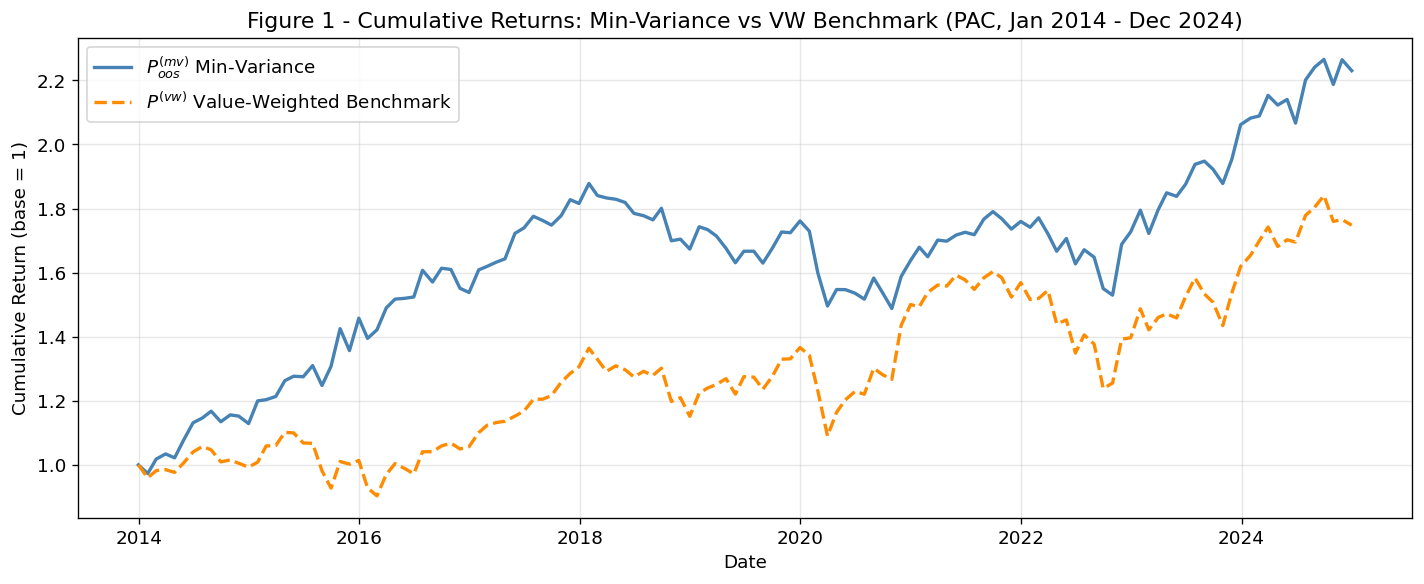

In [20]:
def cumulative_growth_index(monthly_returns):
    """Growth of 1 monetary unit invested at the start of the performance sample."""
    r = np.asarray(monthly_returns, dtype=float)
    return np.r_[1.0, np.cumprod(1 + r)]


plot_base_date = pd.Timestamp(year=PERF_YEARS[0] - 1, month=12, day=31)
dates  = pd.DatetimeIndex([plot_base_date]).append(pd.DatetimeIndex(all_months))
cum_mv = cumulative_growth_index(all_mv_returns)
cum_vw = cumulative_growth_index(all_vw_returns)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, cum_mv, label=r'$P_{oos}^{(mv)}$ Min-Variance',      color='steelblue',  lw=2)
ax.plot(dates, cum_vw, label=r'$P^{(vw)}$ Value-Weighted Benchmark', color='darkorange', lw=2, ls='--')
ax.set_title('Figure 1 - Cumulative Returns: Min-Variance vs VW Benchmark (PAC, Jan 2014 - Dec 2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (base = 1)')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_cumulative_returns_part1.png', dpi=150, bbox_inches='tight')
plt.show()


### Table T4 — Portfolio Composition (Top 10 weights, Dec 2013)

In [21]:
alpha_2013 = results_mv[2013]["weights"]
isins_2013 = results_mv[2013]["isins"]

df_comp = pd.DataFrame({
    "ISIN":     isins_2013,
    "Name":     [isin_to_name.get(i, i) for i in isins_2013],
    "Weight %": alpha_2013 * 100
}).sort_values("Weight %", ascending=False).head(10).reset_index(drop=True)

df_comp["Weight %"] = df_comp["Weight %"].round(3)
print("Table T4 — Top 10 Firms by Weight in P_oos^(mv) (Dec 2013 rebalancing):")
print(df_comp.to_string(index=False))

Table T4 — Top 10 Firms by Weight in P_oos^(mv) (Dec 2013 rebalancing):
        ISIN                          Name  Weight %
HK0006000050         POWER ASSETS HOLDINGS    13.474
HK0002007356                  CLP HOLDINGS    10.582
JP3982100004 LAWSON DEAD - DELIST.24/07/24     8.287
JP3414750004                   SEIKO EPSON     8.218
JP3977400005                        RINNAI     7.004
JP3260800002           KINTETSU GROUP HDG.     5.508
JP3429800000                  ANA HOLDINGS     4.033
HK0003000038       HONG KONG AND CHINA GAS     3.485
JP3573000001                     TOKYO GAS     3.060
JP3357200009                      SHIMADZU     2.667


## 5. Part II — Carbon Metrics

### 5a. Carbon Intensity (CI)

$$CI_{i,Y} = \frac{E_{i,Y}}{\text{Rev}_{i,Y} / 1000} \quad [\text{tCO}_2 / \text{M USD}]$$

Revenue is in **thousands USD** → divide by 1000 to get millions.

In [22]:
rev_millions = rev_y_filled / 1000.0 # kUSD → MUSD
rev_millions = rev_millions.replace(0, np.nan)  # à ajouter ici          
CI = scope1_y_filled / rev_millions           # tCO2 / MUSD
CI = CI.replace([np.inf, -np.inf], np.nan)

print(f"CI matrix shape: {CI.shape}")
print(f"Non-NaN CI values in 2013: {CI[2013].notna().sum()}")

CI matrix shape: (510, 27)
Non-NaN CI values in 2013: 260


### 5b. WACI and Carbon Footprint Functions

$$\text{WACI}_Y^{(p)} = \sum_i \alpha_i \cdot CI_{i,Y} \qquad
\text{CF}_Y^{(p)} = \sum_i \alpha_i \cdot \frac{E_{i,Y}}{\text{Cap}_{i,Y}}$$

In [23]:
def compute_waci(alpha, isins, CI, Y):
    ci = CI.loc[isins, Y].values
    ci = np.nan_to_num(ci, nan=0.0)
    return float(alpha @ ci)


def _ecap_vec(isins, scope1_y_filled, mktcap_y_clean, Y):
    """Vector of E_i / Cap_i for the carbon footprint linear constraint."""
    E   = np.nan_to_num(scope1_y_filled.loc[isins, Y].values.astype(float), nan=0.0)
    Cap = mktcap_y_clean.loc[isins, Y].values.astype(float)
    Cap = np.where(np.isnan(Cap) | (Cap == 0), np.inf, Cap)
    return E / Cap


def compute_cf(alpha, isins, scope1_y_filled, mktcap_y_clean, Y):
    """CF = Σ α_i × (E_i / Cap_i)  [tCO2 / MUSD market cap]"""
    return float(alpha @ _ecap_vec(isins, scope1_y_filled, mktcap_y_clean, Y))


def compute_cf_vw(isins, scope1_y_filled, mktcap_y_clean, Y):
    """VW carbon footprint using the same E_i/Cap_i vector as weighted portfolios."""
    cap = mktcap_y_clean.loc[isins, Y].astype(float)
    total_cap = cap.fillna(0).sum()
    if total_cap <= 0:
        return np.nan
    alpha_vw = cap.fillna(0).values / total_cap
    return compute_cf(alpha_vw, isins, scope1_y_filled, mktcap_y_clean, Y)


print("Carbon metric functions defined.")


Carbon metric functions defined.


### 5c. Compute WACI and CF for MV and VW

In [24]:
carbon_mv = {}  # Y → {waci, cf}
carbon_vw = {}  # Y → {waci, cf}

for Y in REBALANCE_YEARS:
    if Y not in results_mv:
        continue
    I_Y      = results_mv[Y]["isins"]
    alpha_mv = results_mv[Y]["weights"]

    # VW weights from annual market cap at Dec Y
    cap_Y    = mktcap_y_clean.loc[I_Y, Y].fillna(0).values.astype(float)
    alpha_vw_Y = cap_Y / cap_Y.sum() if cap_Y.sum() > 0 else np.ones(len(I_Y)) / len(I_Y)

    carbon_mv[Y] = {
        "waci":     compute_waci(alpha_mv, I_Y, CI, Y),
        "cf":       compute_cf(alpha_mv, I_Y, scope1_y_filled, mktcap_y_clean, Y),
        "alpha_vw": alpha_vw_Y,
    }
    carbon_vw[Y] = {
        "waci": compute_waci(alpha_vw_Y, I_Y, CI, Y),
        "cf":   compute_cf_vw(I_Y, scope1_y_filled, mktcap_y_clean, Y),
    }

print(f"{'Year':>4} | {'WACI_mv':>10} | {'WACI_vw':>10} | {'CF_mv':>10} | {'CF_vw':>10}")
print("-" * 55)
for Y in REBALANCE_YEARS:
    if Y in carbon_mv:
        print(f"{Y:>4} | {carbon_mv[Y]['waci']:>10.1f} | {carbon_vw[Y]['waci']:>10.1f} | "
              f"{carbon_mv[Y]['cf']:>10.4f} | {carbon_vw[Y]['cf']:>10.4f}")

Year |    WACI_mv |    WACI_vw |      CF_mv |      CF_vw
-------------------------------------------------------
2013 |     1482.0 |      192.8 |   795.2219 |   229.4574
2014 |     1250.2 |      176.8 |   746.6472 |   210.2148
2015 |     3147.9 |      348.6 |   475.1600 |   219.0148
2016 |     4400.9 |      446.5 |   371.2554 |   266.9543
2017 |     3218.1 |      521.0 |   449.9793 |   234.4599
2018 |     4144.6 |      397.3 |   597.8811 |   182.1630
2019 |     1701.4 |      301.0 |   529.7532 |   195.1624
2020 |     1097.6 |      243.3 |   530.8603 |   155.6099
2021 |     1739.9 |      202.3 |   654.9698 |   152.2077
2022 |      737.2 |      228.5 |   453.4011 |   153.0639
2023 |      261.5 |      205.8 |   398.8409 |   155.2760


### Table T3 & Figure 8 — Top 10 Carbon-Intensive Firms

Table T3 — Top 10 Carbon-Intensive Firms (PAC Investment Set 2013, Scope 1):
        ISIN                  Name  CI 2013 (tCO2/MUSD)
JP3551200003       ELEC.POWER DEV.               7599.2
HK0006000050 POWER ASSETS HOLDINGS               6673.8
JP3845400005   HOKURIKU ELEC.POWER               3438.2
JP3522200009    CHUGOKU ELEC.POWER               3122.7
HK0019000162     SWIRE PACIFIC 'A'               2844.1
HK0002007356          CLP HOLDINGS               2829.3
JP3850200001   HOKKAIDO ELEC.POWER               2344.0
JP3605400005  TOHOKU ELECTRIC PWR.               2103.6
JP3526600006      CHUBU ELEC.POWER               1913.8
JP3228600007  KANSAI ELECTRIC PWR.               1682.8


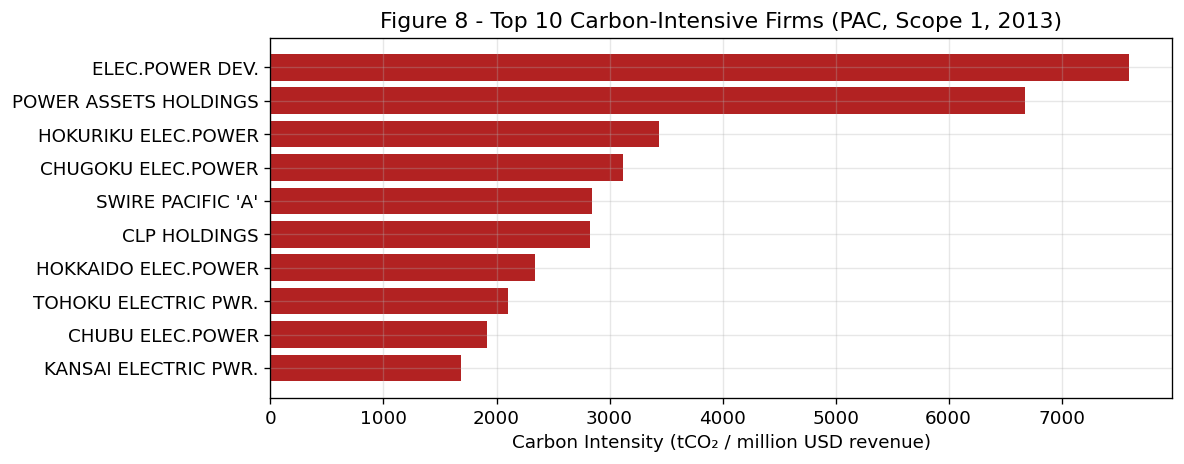

In [25]:
ci_2013    = CI.loc[investment_sets[2013], 2013].dropna().sort_values(ascending=False)
top10_ci   = pd.DataFrame({
    "ISIN":             ci_2013.index[:10],
    "Name":             [isin_to_name.get(i, i) for i in ci_2013.index[:10]],
    "CI 2013 (tCO2/MUSD)": ci_2013.values[:10].astype(float).round(1)
})
print("Table T3 — Top 10 Carbon-Intensive Firms (PAC Investment Set 2013, Scope 1):")
print(top10_ci.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top10_ci["Name"].str[:40], top10_ci["CI 2013 (tCO2/MUSD)"], color='firebrick')
ax.set_xlabel('Carbon Intensity (tCO₂ / million USD revenue)')
ax.set_title('Figure 8 - Top 10 Carbon-Intensive Firms (PAC, Scope 1, 2013)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig8_top10_carbon_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Part II — Carbon-Constrained Portfolios

### 6a–b. Constrained Optimisation Solvers

In [26]:
def solve_mv_carbon(Sigma, cf_vec, cf_limit):
    """
    Min-variance QP with linear carbon footprint constraint:
      min α'Σα  s.t.  cf_vec @ α ≤ cf_limit,  Σα=1,  α≥0
    Falls back to relaxed limit if infeasible (documented below).
    Returns (weights, actual_limit_used)
    """
    N = Sigma.shape[0]
    alpha = cp.Variable(N)
    objective = cp.Minimize(cp.quad_form(alpha, Sigma))

    for limit in [cf_limit, cf_limit * 1.10, cf_limit * 1.50, None]:
        if limit is None:
            # Last resort: unconstrained MV
            print("    WARNING: CF constraint infeasible — returning unconstrained MV.")
            return solve_min_variance(Sigma), np.nan
        constraints = [cp.sum(alpha) == 1, alpha >= 0, cf_vec @ alpha <= limit]
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8, max_iter=20000)
        if prob.status in ["optimal", "optimal_inaccurate"]:
            w = np.clip(np.array(alpha.value).flatten(), 0, None)
            return w / w.sum(), limit


def solve_te_carbon(Sigma, alpha_vw, cf_vec, cf_limit):
    """
    Tracking-error minimisation with carbon constraint:
      min (α-α_vw)'Σ(α-α_vw)  s.t.  cf_vec @ α ≤ cf_limit,  Σα=1,  α≥0
    Returns (weights, actual_limit_used)
    """
    N = Sigma.shape[0]
    alpha = cp.Variable(N)
    diff  = alpha - alpha_vw
    objective = cp.Minimize(cp.quad_form(diff, Sigma))

    for limit in [cf_limit, cf_limit * 1.10, cf_limit * 1.50, None]:
        if limit is None:
            print("    WARNING: TE constraint infeasible — returning VW weights.")
            return alpha_vw.copy(), np.nan
        constraints = [cp.sum(alpha) == 1, alpha >= 0, cf_vec @ alpha <= limit]
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8, max_iter=20000)
        if prob.status in ["optimal", "optimal_inaccurate"]:
            w = np.clip(np.array(alpha.value).flatten(), 0, None)
            return w / w.sum(), limit


print("Constrained optimisation solvers defined.")

Constrained optimisation solvers defined.


### 6c. Run All Three Carbon-Constrained Strategies

| Portfolio | Objective | CF Constraint |
|-----------|-----------|---------------|
| $P_{oos}^{(mv)}(0.5)$ | Min-variance | CF ≤ 50% × CF$^{(mv)}$ |
| $P_{oos}^{(vw)}(0.5)$ | Tracking-error vs VW | CF ≤ 50% × CF$^{(vw)}$ |
| $P_{oos}^{(vw)}(NZ)$  | Tracking-error vs VW | CF ≤ $(1−10\%)^{Y−2012}$ × CF$^{(vw)}_{2013}$ |

In [27]:
results_mv50 = {}
results_vw50 = {}
results_nz   = {}

all_mv50_returns = []
all_vw50_returns = []
all_nz_returns   = []

# Net-zero base: VW CF at 2013
cf_base_vw_2013 = carbon_vw[2013]["cf"]
print(f"Net-zero base CF (VW 2013): {cf_base_vw_2013:.6f} tCO2/MUSD cap")
print()

print("Running carbon-constrained optimisations...")
for Y in REBALANCE_YEARS:
    if Y not in results_mv:
        continue
    I_Y       = results_mv[Y]["isins"]
    Sigma     = results_mv[Y]["Sigma"]
    perf_year = Y + 1
    alpha_vw_Y = carbon_mv[Y]["alpha_vw"]

    cf_vec = _ecap_vec(I_Y, scope1_y_filled, mktcap_y_clean, Y)

    # --- P_oos^(mv)(0.5) ---
    cf_limit_mv50         = 0.5 * carbon_mv[Y]["cf"]
    alpha_mv50, lim_mv50  = solve_mv_carbon(Sigma, cf_vec, cf_limit_mv50)
    ret_mv50, _           = compute_portfolio_returns(alpha_mv50, I_Y, ret_m, perf_year)

    # --- P_oos^(vw)(0.5) ---
    cf_limit_vw50         = 0.5 * carbon_vw[Y]["cf"]
    alpha_vw50, lim_vw50  = solve_te_carbon(Sigma, alpha_vw_Y, cf_vec, cf_limit_vw50)
    ret_vw50, _           = compute_portfolio_returns(alpha_vw50, I_Y, ret_m, perf_year)

    # --- P_oos^(vw)(NZ) ---
    cf_limit_nz           = (1 - NZ_THETA) ** (Y - 2013 + 1) * cf_base_vw_2013
    alpha_nz, lim_nz      = solve_te_carbon(Sigma, alpha_vw_Y, cf_vec, cf_limit_nz)
    ret_nz, _             = compute_portfolio_returns(alpha_nz, I_Y, ret_m, perf_year)

    results_mv50[Y] = dict(weights=alpha_mv50, isins=I_Y, returns=ret_mv50,
                           cf=compute_cf(alpha_mv50, I_Y, scope1_y_filled, mktcap_y_clean, Y),
                           waci=compute_waci(alpha_mv50, I_Y, CI, Y),
                           cf_limit=cf_limit_mv50, cf_limit_used=lim_mv50)
    results_vw50[Y] = dict(weights=alpha_vw50, isins=I_Y, returns=ret_vw50,
                           cf=compute_cf(alpha_vw50, I_Y, scope1_y_filled, mktcap_y_clean, Y),
                           waci=compute_waci(alpha_vw50, I_Y, CI, Y),
                           cf_limit=cf_limit_vw50, cf_limit_used=lim_vw50)
    results_nz[Y]   = dict(weights=alpha_nz, isins=I_Y, returns=ret_nz,
                           cf=compute_cf(alpha_nz, I_Y, scope1_y_filled, mktcap_y_clean, Y),
                           waci=compute_waci(alpha_nz, I_Y, CI, Y),
                           cf_limit=cf_limit_nz, cf_limit_used=lim_nz)

    all_mv50_returns.extend(ret_mv50)
    all_vw50_returns.extend(ret_vw50)
    all_nz_returns.extend(ret_nz)

    print(f"  {Y}: CF_mv50={results_mv50[Y]['cf']:.4f} (lim={cf_limit_mv50:.4f}) | "
          f"CF_vw50={results_vw50[Y]['cf']:.4f} (lim={cf_limit_vw50:.4f}) | "
          f"CF_nz={results_nz[Y]['cf']:.4f} (target={cf_limit_nz:.4f})")

print("\nCarbon-constrained optimisations complete.")

Net-zero base CF (VW 2013): 229.457377 tCO2/MUSD cap

Running carbon-constrained optimisations...
  2013: CF_mv50=397.6109 (lim=397.6109) | CF_vw50=114.7286 (lim=114.7287) | CF_nz=206.5116 (target=206.5116)
  2014: CF_mv50=373.3236 (lim=373.3236) | CF_vw50=105.1073 (lim=105.1074) | CF_nz=185.8605 (target=185.8605)
  2015: CF_mv50=237.5800 (lim=237.5800) | CF_vw50=109.5073 (lim=109.5074) | CF_nz=167.2744 (target=167.2744)
  2016: CF_mv50=185.6277 (lim=185.6277) | CF_vw50=133.4771 (lim=133.4771) | CF_nz=150.5470 (target=150.5470)
  2017: CF_mv50=224.9896 (lim=224.9896) | CF_vw50=117.2299 (lim=117.2299) | CF_nz=135.4923 (target=135.4923)
  2018: CF_mv50=298.9406 (lim=298.9406) | CF_vw50=91.0815 (lim=91.0815) | CF_nz=121.9431 (target=121.9431)
  2019: CF_mv50=264.8766 (lim=264.8766) | CF_vw50=97.5812 (lim=97.5812) | CF_nz=109.7488 (target=109.7488)
  2020: CF_mv50=265.4302 (lim=265.4302) | CF_vw50=77.8049 (lim=77.8049) | CF_nz=98.7739 (target=98.7739)
  2021: CF_mv50=327.4849 (lim=327.4849

**Note:** Ledoit-Wolf shrinkage est utilisé dans `estimate_moments` pour garantir une matrice de covariance plein rang lorsque N > τ (à partir de déc. 2017).

## 7. Final Comparison & Report Outputs

### Table T1 — Summary Statistics (5 Portfolios)

In [28]:
stats_mv50 = performance_stats(all_mv50_returns)
stats_vw50 = performance_stats(all_vw50_returns)
stats_nz   = performance_stats(all_nz_returns)

print(f"Risk-free rate used in Sharpe ratios: {RF_ANN:.4%} ({RF_SOURCE})")

df_stats = pd.DataFrame({
    r"$P_{oos}^{(mv)}$":       stats_mv,
    r"$P^{(vw)}$":             stats_vw,
    r"$P_{oos}^{(mv)}(0.5)$": stats_mv50,
    r"$P_{oos}^{(vw)}(0.5)$": stats_vw50,
    r"$P_{oos}^{(vw)}(NZ)$":  stats_nz,
}).T

disp = df_stats.copy()
for col in ["Ann. Return", "Ann. Volatility", "Min Monthly", "Max Monthly", "Cum. Return"]:
    disp[col] = disp[col].map("{:.2%}".format)
disp["Sharpe Ratio"] = disp["Sharpe Ratio"].map("{:.3f}".format)

print("Table T1 — Performance Summary (Jan 2014 – Dec 2024):")
print(disp.to_string())


Risk-free rate used in Sharpe ratios: 1.6181% (FRED TB3MS (Board of Governors/Federal Reserve Bank of St. Louis))
Table T1 — Performance Summary (Jan 2014 – Dec 2024):
                      Ann. Return Ann. Volatility Sharpe Ratio Min Monthly Max Monthly Cum. Return
$P_{oos}^{(mv)}$            7.56%          10.89%        0.546      -7.52%      10.37%     123.03%
$P^{(vw)}$                  5.21%          13.53%        0.265     -11.44%      13.32%      74.80%
$P_{oos}^{(mv)}(0.5)$       7.55%          11.07%        0.536      -7.64%      10.90%     122.80%
$P_{oos}^{(vw)}(0.5)$       5.30%          13.57%        0.271     -11.87%      12.94%      76.52%
$P_{oos}^{(vw)}(NZ)$        5.28%          13.59%        0.270     -11.89%      12.95%      76.20%


### Table T2 — Annual WACI and CF by Portfolio

In [29]:
rows = []
for Y in REBALANCE_YEARS:
    if Y not in carbon_mv:
        continue
    rows.append({
        "Year":         Y,
        "WACI_mv":      carbon_mv[Y]["waci"],
        "WACI_vw":      carbon_vw[Y]["waci"],
        "WACI_mv50":    results_mv50.get(Y, {}).get("waci", np.nan),
        "WACI_vw50":    results_vw50.get(Y, {}).get("waci", np.nan),
        "WACI_nz":      results_nz.get(Y, {}).get("waci", np.nan),
        "CF_mv":        carbon_mv[Y]["cf"],
        "CF_vw":        carbon_vw[Y]["cf"],
        "CF_mv50":      results_mv50.get(Y, {}).get("cf", np.nan),
        "CF_vw50":      results_vw50.get(Y, {}).get("cf", np.nan),
        "CF_nz":        results_nz.get(Y, {}).get("cf", np.nan),
        "CF_nz_target": (1 - NZ_THETA) ** (Y - 2013 + 1) * cf_base_vw_2013
    })

df_carbon = pd.DataFrame(rows).set_index("Year")
print("Table T2 — Annual Carbon Metrics (WACI and CF):")
print(df_carbon.round(4).to_string())

Table T2 — Annual Carbon Metrics (WACI and CF):
        WACI_mv   WACI_vw  WACI_mv50  WACI_vw50   WACI_nz     CF_mv     CF_vw   CF_mv50   CF_vw50     CF_nz  CF_nz_target
Year                                                                                                                     
2013  1482.0070  192.7964  1281.4608   149.4194  183.7246  795.2219  229.4574  397.6109  114.7286  206.5116      206.5116
2014  1250.2277  176.7797  1014.2390   126.7964  164.6577  746.6472  210.2148  373.3236  105.1073  185.8605      185.8605
2015  3147.8619  348.5912  3184.8410   292.4903  322.8436  475.1600  219.0148  237.5800  109.5073  167.2744      167.2744
2016  4400.8656  446.5322  4487.1453   389.7079  395.7049  371.2554  266.9543  185.6277  133.4771  150.5470      150.5470
2017  3218.0564  521.0393  2933.6025   465.9795  477.6667  449.9793  234.4599  224.9896  117.2299  135.4923      135.4923
2018  4144.6498  397.3082  3590.4952   350.5245  369.0929  597.8811  182.1630  298.9406   91.0815 

### Figure 2 — WACI Evolution

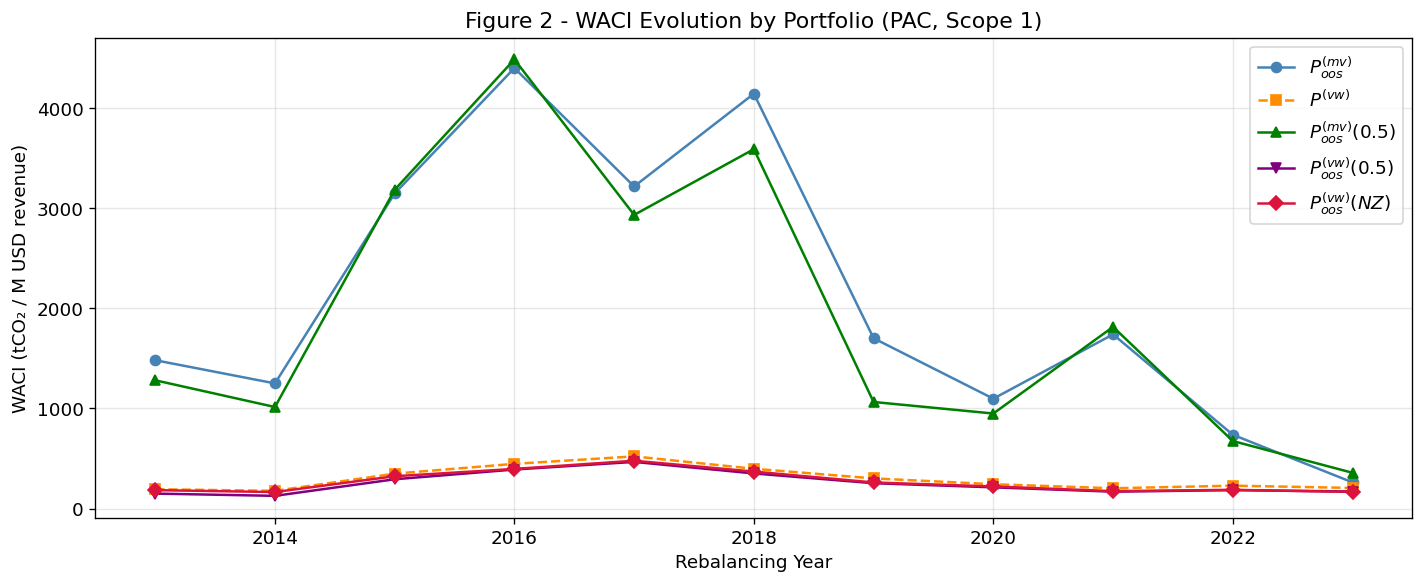

In [30]:
years = df_carbon.index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, df_carbon["WACI_mv"],   label=r'$P_{oos}^{(mv)}$',       marker='o', color='steelblue')
ax.plot(years, df_carbon["WACI_vw"],   label=r'$P^{(vw)}$',             marker='s', color='darkorange', ls='--')
ax.plot(years, df_carbon["WACI_mv50"], label=r'$P_{oos}^{(mv)}(0.5)$',  marker='^', color='green')
ax.plot(years, df_carbon["WACI_vw50"], label=r'$P_{oos}^{(vw)}(0.5)$',  marker='v', color='purple')
ax.plot(years, df_carbon["WACI_nz"],   label=r'$P_{oos}^{(vw)}(NZ)$',   marker='D', color='crimson')
ax.set_title('Figure 2 - WACI Evolution by Portfolio (PAC, Scope 1)')
ax.set_xlabel('Rebalancing Year')
ax.set_ylabel('WACI (tCO₂ / M USD revenue)')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_waci_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 — Carbon Footprint Evolution + Net-Zero Trajectory

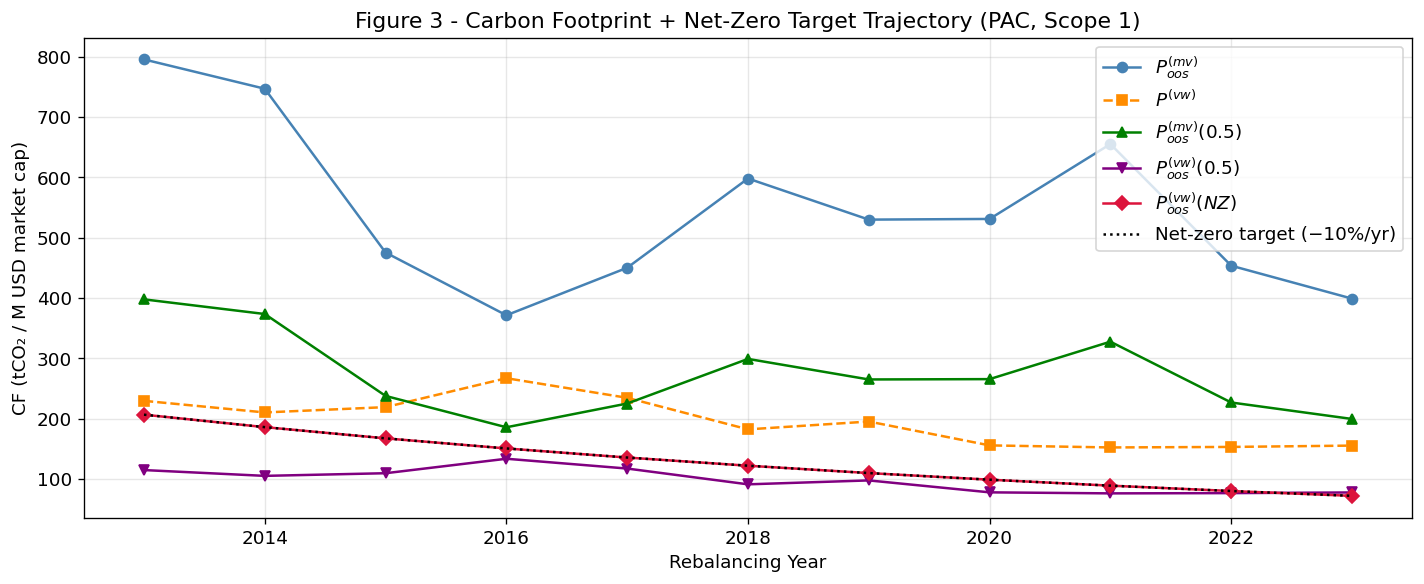

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, df_carbon["CF_mv"],        label=r'$P_{oos}^{(mv)}$',           marker='o', color='steelblue')
ax.plot(years, df_carbon["CF_vw"],        label=r'$P^{(vw)}$',                 marker='s', color='darkorange', ls='--')
ax.plot(years, df_carbon["CF_mv50"],      label=r'$P_{oos}^{(mv)}(0.5)$',      marker='^', color='green')
ax.plot(years, df_carbon["CF_vw50"],      label=r'$P_{oos}^{(vw)}(0.5)$',      marker='v', color='purple')
ax.plot(years, df_carbon["CF_nz"],        label=r'$P_{oos}^{(vw)}(NZ)$',       marker='D', color='crimson')
ax.plot(years, df_carbon["CF_nz_target"], label='Net-zero target (−10%/yr)',    ls=':',     color='black', lw=1.5)
ax.set_title('Figure 3 - Carbon Footprint + Net-Zero Target Trajectory (PAC, Scope 1)')
ax.set_xlabel('Rebalancing Year')
ax.set_ylabel('CF (tCO₂ / M USD market cap)')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_cf_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4 — Cumulative Returns: P_oos^(mv) vs P_oos^(mv)(0.5)

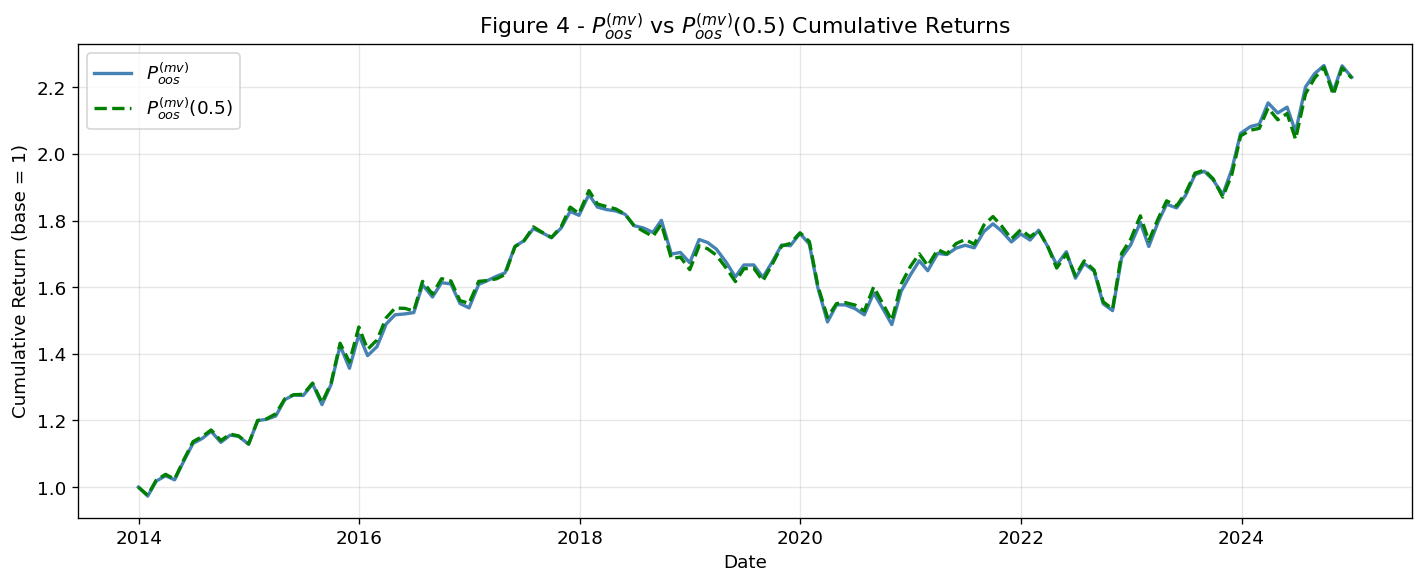

In [32]:
cum_mv50 = cumulative_growth_index(all_mv50_returns)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, cum_mv,   label=r'$P_{oos}^{(mv)}$',        color='steelblue', lw=2)
ax.plot(dates, cum_mv50, label=r'$P_{oos}^{(mv)}(0.5)$',   color='green',     lw=2, ls='--')
ax.set_title(r'Figure 4 - $P_{oos}^{(mv)}$ vs $P_{oos}^{(mv)}(0.5)$ Cumulative Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (base = 1)')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_cumret_mv_vs_mv50.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 5 — Cumulative Returns: P^(vw) vs P_oos^(vw)(0.5)

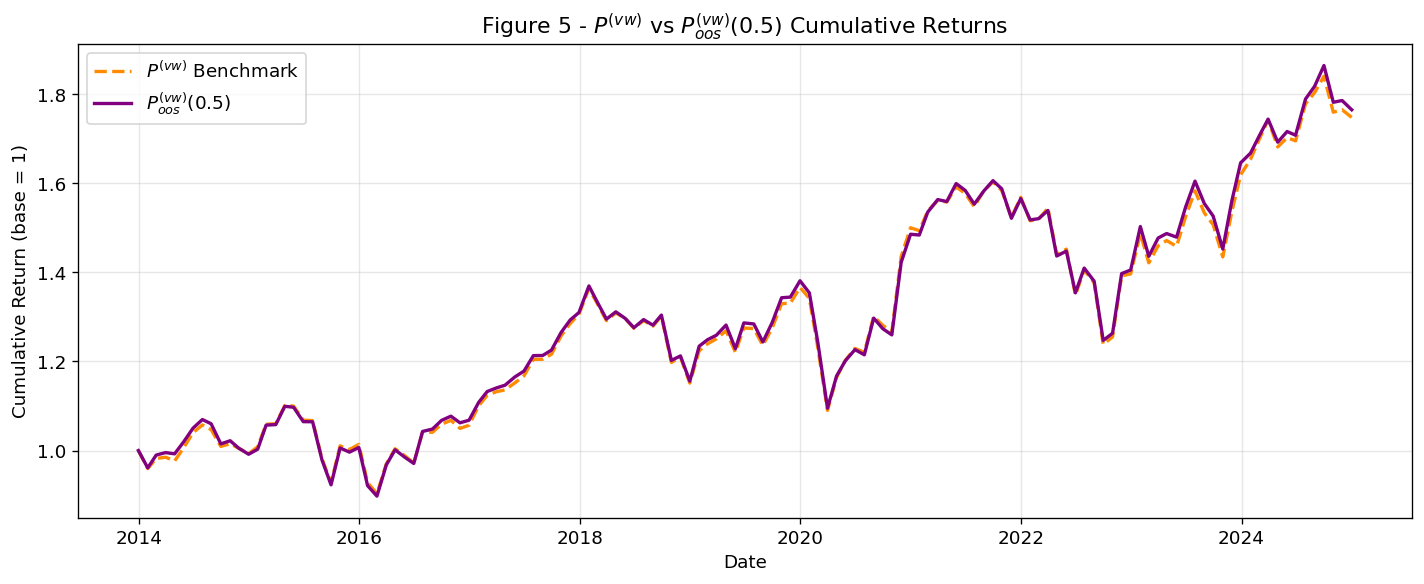

In [33]:
cum_vw50 = cumulative_growth_index(all_vw50_returns)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, cum_vw,   label=r'$P^{(vw)}$ Benchmark',      color='darkorange', lw=2, ls='--')
ax.plot(dates, cum_vw50, label=r'$P_{oos}^{(vw)}(0.5)$',     color='purple',     lw=2)
ax.set_title(r'Figure 5 - $P^{(vw)}$ vs $P_{oos}^{(vw)}(0.5)$ Cumulative Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (base = 1)')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_cumret_vw_vs_vw50.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 6 — Final Comparison: VW, VW(0.5), VW(NZ)

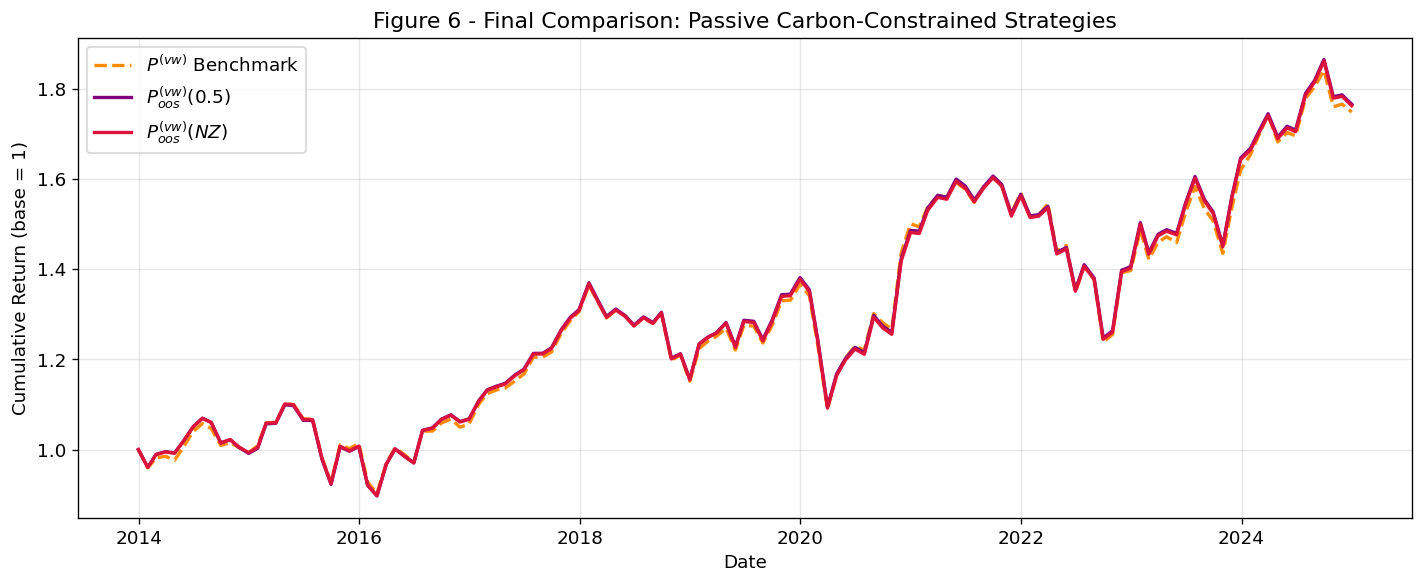

In [34]:
cum_nz = cumulative_growth_index(all_nz_returns)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, cum_vw,   label=r'$P^{(vw)}$ Benchmark',   color='darkorange', lw=2, ls='--')
ax.plot(dates, cum_vw50, label=r'$P_{oos}^{(vw)}(0.5)$',  color='purple',     lw=2)
ax.plot(dates, cum_nz,   label=r'$P_{oos}^{(vw)}(NZ)$',   color='crimson',    lw=2)
ax.set_title('Figure 6 - Final Comparison: Passive Carbon-Constrained Strategies')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (base = 1)')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 7 — Weight Evolution (Top 10 Firms in P_oos^(mv))

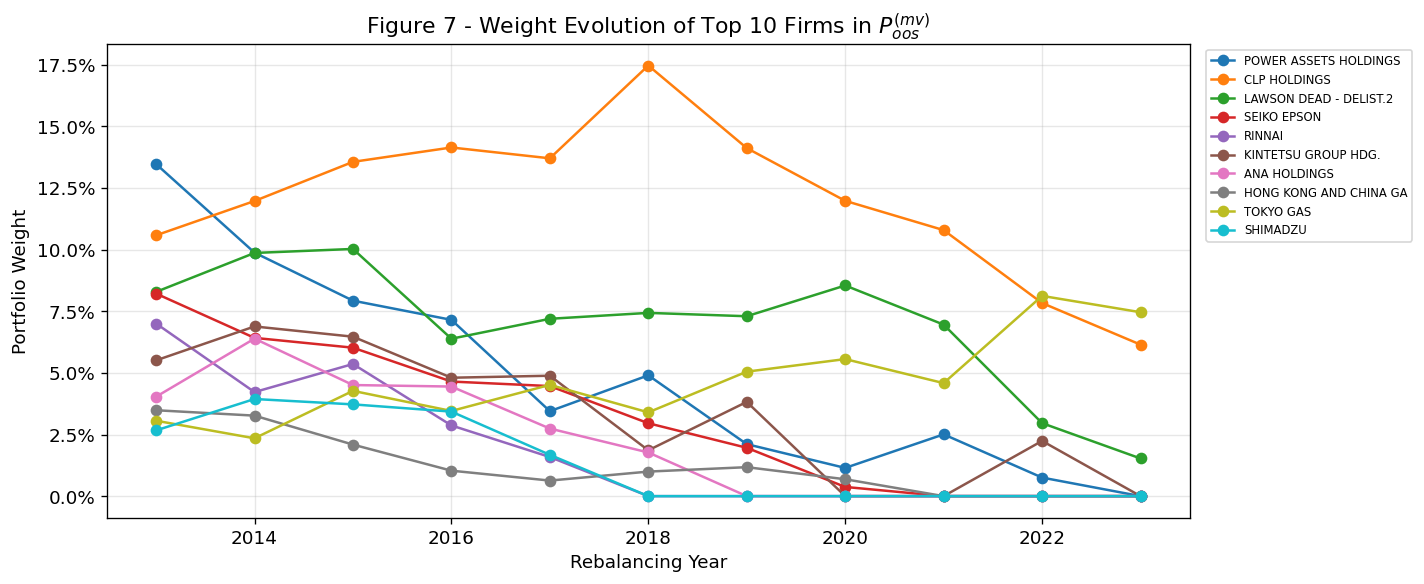

In [35]:
top10_isins_2013 = (
    pd.Series(results_mv[2013]["weights"], index=results_mv[2013]["isins"])
    .sort_values(ascending=False).head(10).index.tolist()
)

weight_evo = {isin: {} for isin in top10_isins_2013}
for Y in REBALANCE_YEARS:
    if Y not in results_mv:
        continue
    w = pd.Series(results_mv[Y]["weights"], index=results_mv[Y]["isins"])
    for isin in top10_isins_2013:
        weight_evo[isin][Y] = w.get(isin, 0.0)

fig, ax = plt.subplots(figsize=(12, 5))
for isin in top10_isins_2013:
    ys = sorted(weight_evo[isin])
    ws = [weight_evo[isin][y] for y in ys]
    ax.plot(ys, ws, marker='o', label=isin_to_name.get(isin, isin)[:22])

ax.set_title(r'Figure 7 - Weight Evolution of Top 10 Firms in $P_{oos}^{(mv)}$')
ax.set_xlabel('Rebalancing Year')
ax.set_ylabel('Portfolio Weight')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig7_weight_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 9 — Portfolio Composition Change: $P_{oos}^{(mv)}$ vs $P_{oos}^{(mv)}(0.5)$

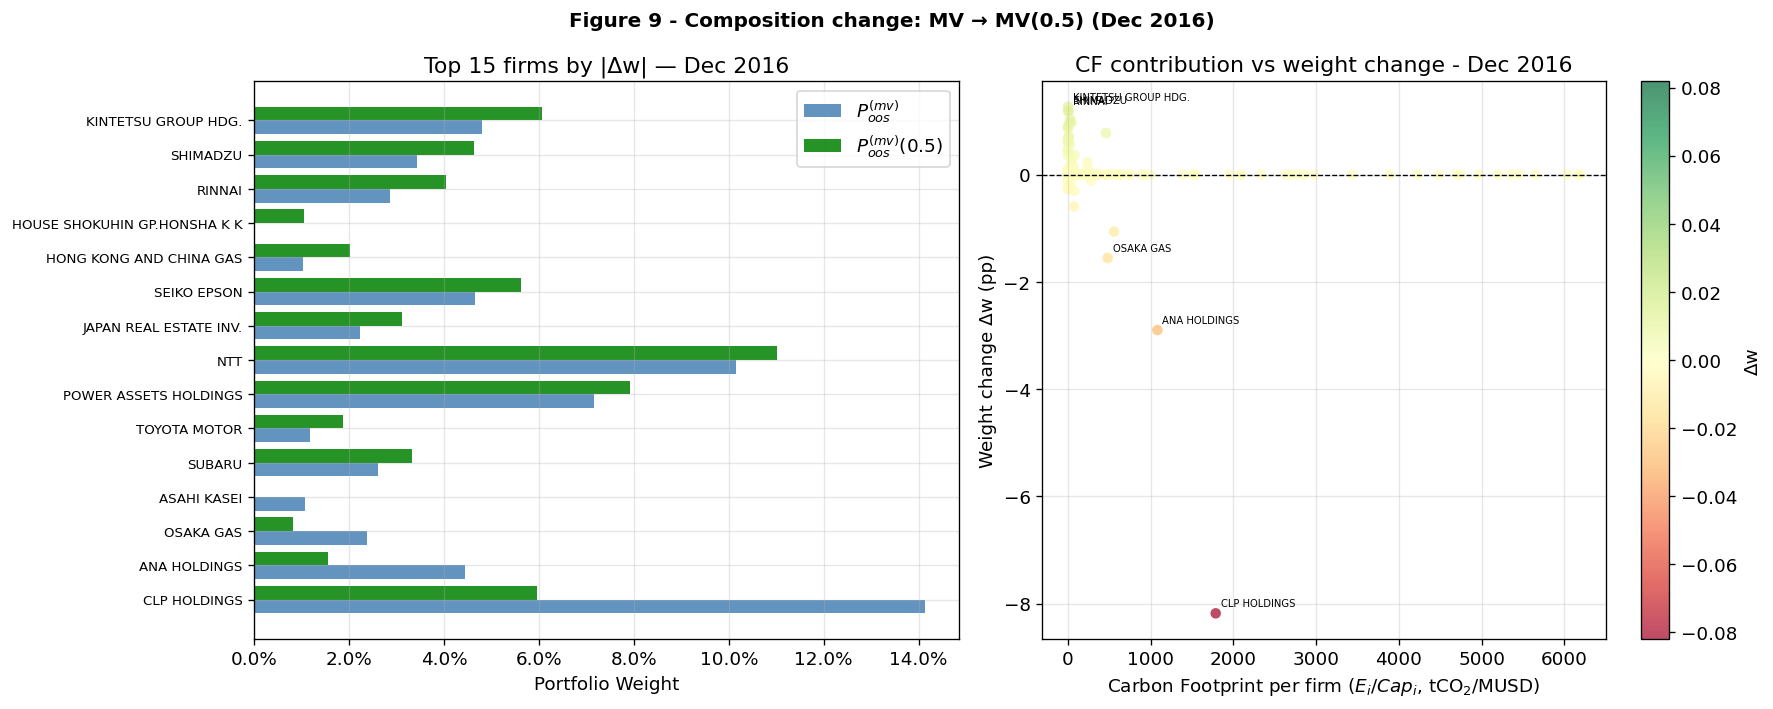

Weight in top-10 firms  MV:     65.4%
Weight in top-10 firms  MV(0.5):63.1%
CF 2016: MV=371.26 -> MV50=185.63 tCO2/MUSD cap


In [36]:
# Reference year: 2016 (highest WACI_mv = 4401, most binding CF constraint)
Y_ref = 2016

I_Y    = results_mv[Y_ref]['isins']
w_mv   = pd.Series(results_mv[Y_ref]['weights'],   index=I_Y)
w_mv50 = pd.Series(results_mv50[Y_ref]['weights'], index=I_Y)
delta_w = w_mv50 - w_mv  # >0 = gained weight, <0 = lost weight

# CF per firm (E_i / Cap_i)
ecap = pd.Series(_ecap_vec(I_Y, scope1_y_filled, mktcap_y_clean, Y_ref), index=I_Y)
ecap = ecap.replace([np.inf, -np.inf], np.nan)

# Top 15 firms by |Δw|
top_changed = delta_w.abs().nlargest(15).index
df_comp = pd.DataFrame({
    'MV':      w_mv[top_changed].values,
    'MV(0.5)': w_mv50[top_changed].values,
    'delta':   delta_w[top_changed].values,
}, index=[isin_to_name.get(i, i)[:28] for i in top_changed])
df_comp = df_comp.sort_values('delta', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: weight comparison ---
ax = axes[0]
y_pos = range(len(df_comp))
ax.barh(list(y_pos), df_comp['MV'], height=0.4, align='center',
        label=r'$P_{oos}^{(mv)}$', color='steelblue', alpha=0.85)
ax.barh([y + 0.4 for y in y_pos], df_comp['MV(0.5)'], height=0.4, align='center',
        label=r'$P_{oos}^{(mv)}(0.5)$', color='green', alpha=0.85)
ax.set_yticks([y + 0.2 for y in y_pos])
ax.set_yticklabels(df_comp.index, fontsize=8)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Portfolio Weight')
ax.set_title(f'Top 15 firms by |\u0394w| - Dec {Y_ref}')
ax.legend()

# --- Panel 2: scatter E/Cap vs delta_w ---
ax2 = axes[1]
valid = ecap.notna() & (ecap < ecap.quantile(0.98))
sc = ax2.scatter(ecap[valid], delta_w[valid] * 100,
                 c=delta_w[valid], cmap='RdYlGn', alpha=0.7,
                 edgecolors='none', s=40,
                 vmin=-delta_w[valid].abs().max(), vmax=delta_w[valid].abs().max())
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_xlabel(r'Carbon Footprint per firm ($E_i / Cap_i$, tCO$_2$/MUSD)')
ax2.set_ylabel('Weight change \u0394w (pp)')
ax2.set_title(f'CF contribution vs weight change - Dec {Y_ref}')
plt.colorbar(sc, ax=ax2, label='\u0394w')

# Label most impacted firms
top_label = delta_w[valid].abs().nlargest(6).index
for isin in top_label:
    if isin in ecap.index and pd.notna(ecap[isin]) and ecap[isin] < ecap.quantile(0.98):
        ax2.annotate(isin_to_name.get(isin, isin)[:20],
                     xy=(ecap[isin], delta_w[isin] * 100),
                     fontsize=6, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')

plt.suptitle(
    'Figure 9 - Composition change: MV → MV(0.5)'
    f' (Dec {Y_ref})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_composition_change_mv50.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Weight in top-10 firms  MV:     {w_mv.nlargest(10).sum():.1%}')
print(f'Weight in top-10 firms  MV(0.5):{w_mv50.nlargest(10).sum():.1%}')
print(f'CF {Y_ref}: MV={carbon_mv[Y_ref]["cf"]:.2f} -> MV50={results_mv50[Y_ref]["cf"]:.2f} tCO2/MUSD cap')


### Excel Export — April 12 Preliminary Submission

In [37]:
df_monthly = pd.DataFrame({
    "Date":       all_months,
    "MV_Return":  all_mv_returns,
    "VW_Return":  all_vw_returns,
})

df_summary = pd.DataFrame({
    "Portfolio":       ["P_oos^(mv)", "P^(vw)"],
    "Ann. Return":     [stats_mv["Ann. Return"],     stats_vw["Ann. Return"]],
    "Ann. Volatility": [stats_mv["Ann. Volatility"], stats_vw["Ann. Volatility"]],
    "Risk-Free Rate":  [RF_ANN,                      RF_ANN],
    "Sharpe Ratio":    [stats_mv["Sharpe Ratio"],    stats_vw["Sharpe Ratio"]],
    "Min Monthly":     [stats_mv["Min Monthly"],     stats_vw["Min Monthly"]],
    "Max Monthly":     [stats_mv["Max Monthly"],     stats_vw["Max Monthly"]],
    "Cum. Return":     [stats_mv["Cum. Return"],     stats_vw["Cum. Return"]],
})

df_rf = rf_monthly.copy()
df_rf["TB3MS_decimal_ann"] = df_rf[RF_SERIES] / 100.0

df_rf_meta = pd.DataFrame({
    "Item": ["Series", "Source", "Sample", "Average annualized risk-free rate"],
    "Value": [RF_SERIES, RF_SOURCE, f"{RF_START.date()} to {RF_END.date()}", RF_ANN],
})

out = Path("SAAM_PartI_Results.xlsx")
with pd.ExcelWriter(out, engine="openpyxl") as writer:
    df_monthly.to_excel(writer, sheet_name="Monthly Returns", index=False)
    df_summary.to_excel(writer, sheet_name="Summary Stats",   index=False)
    df_rf.to_excel(writer, sheet_name="Risk-Free Monthly", index=False)
    df_rf_meta.to_excel(writer, sheet_name="Risk-Free Meta", index=False)

print(f"Preliminary submission file saved: {out}")


Preliminary submission file saved: SAAM_PartI_Results.xlsx
